# Goal: Understand what is happening by doing EDA

1.summarize data
2.find patterns
3.identify trends
4.no deep conclusions yet


In [126]:
import pandas as pd
df=pd.read_csv("../data/02_processed/customer_data_cleaned.csv")


In [62]:
# 1. Demographics undesranding

df["age"].describe() # This shows, means centered around 44.with no significant outliers. Most individuals fall between 30–60 years,


count    3900.000000
mean       44.068462
std        15.207589
min        18.000000
25%        31.000000
50%        44.000000
75%        57.000000
max        70.000000
Name: age, dtype: float64

In [ ]:
df["gender"].value_counts()



gender
Male      2652
Female    1248
Name: count, dtype: int64

In [ ]:
df['age_group'].value_counts()
df['gender'].value_counts(normalize=True) * 100

age_group
46_60       1135
26_35        742
36_45        729
60_plus      723
18_25        502
under_18      69
Name: count, dtype: int64

In [26]:
# Most popular items purchased
df['item_purchased'].value_counts()

item_purchased
Blouse        171
Jewelry       171
Pants         171
Shirt         169
Dress         166
Sweater       164
Jacket        163
Belt          161
Sunglasses    161
Coat          161
Sandals       160
Socks         159
Skirt         158
Shorts        157
Scarf         157
Hat           154
Handbag       153
Hoodie        151
Shoes         150
T-shirt       147
Sneakers      145
Boots         144
Backpack      143
Gloves        140
Jeans         124
Name: count, dtype: int64

age_group
46_60       67711
26_35       44342
36_45       43234
60_plus     43164
18_25       30491
under_18     4139
Name: purchase_amount_(usd), dtype: int64


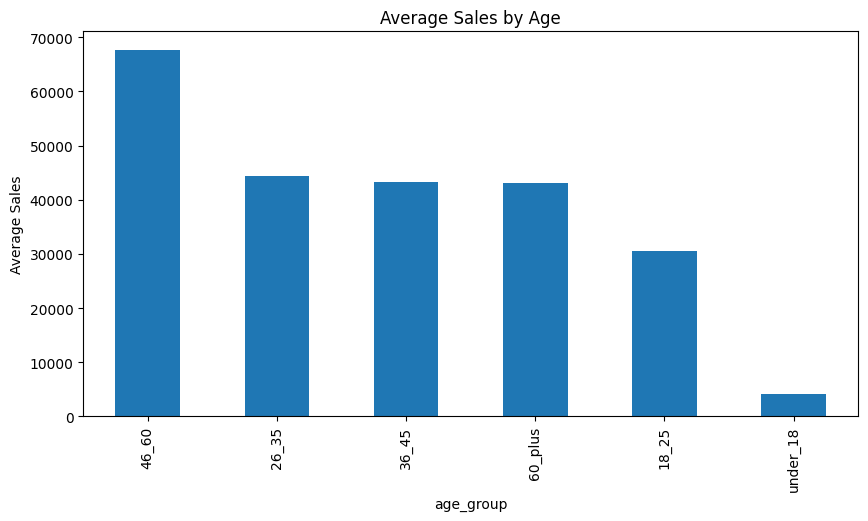

In [95]:
# Q1: Which age group spends the most?
age_spending = df.groupby('age_group')['purchase_amount_(usd)'].sum().sort_values(ascending=False)
print(age_spending)

age_spending.plot(kind='bar', figsize=(10,5), title="Average Sales by Age")
plt.ylabel("Average Sales")
plt.show()

Number of male and females in daaaset gender
Male      2652
Female    1248
Name: count, dtype: int64
 Amount of Purchasesgender_purchase gender
Male      157890
Female     75191
Name: purchase_amount_(usd), dtype: int64


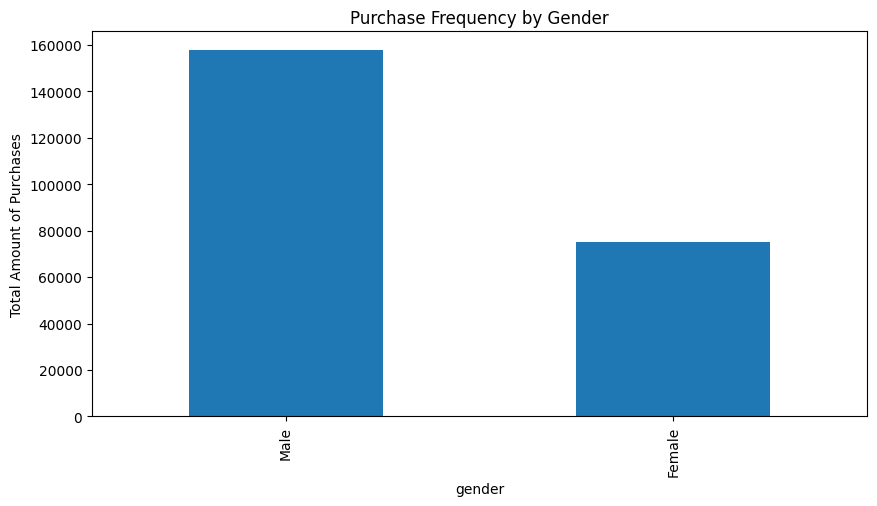

In [99]:
# Q2: Do males or females purchase more frequently?
gender_freq = df['gender'].value_counts()
print("Number of male and females in daaaset",gender_freq)

gender_purchase = df.groupby('gender')['purchase_amount_(usd)'].sum().sort_values(ascending=False)
print(" Amount of Purchasesgender_purchase",gender_purchase)

gender_purchase.plot(kind='bar', figsize=(10,5), title="Purchase Frequency by Gender")
plt.ylabel("Total Amount of Purchases")
plt.show()  

location
Montana           5784
Illinois          5617
California        5605
Idaho             5587
Nevada            5514
Alabama           5261
New York          5257
North Dakota      5220
West Virginia     5174
Nebraska          5172
New Mexico        5014
Minnesota         4977
Pennsylvania      4926
Mississippi       4883
Alaska            4867
Vermont           4860
Louisiana         4848
Virginia          4842
Arkansas          4828
Maryland          4795
Tennessee         4772
Delaware          4758
North Carolina    4742
Texas             4712
Missouri          4691
Indiana           4655
Ohio              4649
Georgia           4645
Washington        4623
Michigan          4533
Utah              4443
South Carolina    4439
Kentucky          4402
Maine             4388
Massachusetts     4384
Oklahoma          4376
Arizona           4326
Wyoming           4309
Oregon            4243
South Dakota      4236
Connecticut       4226
Colorado          4222
New Hampshire     4219
Io

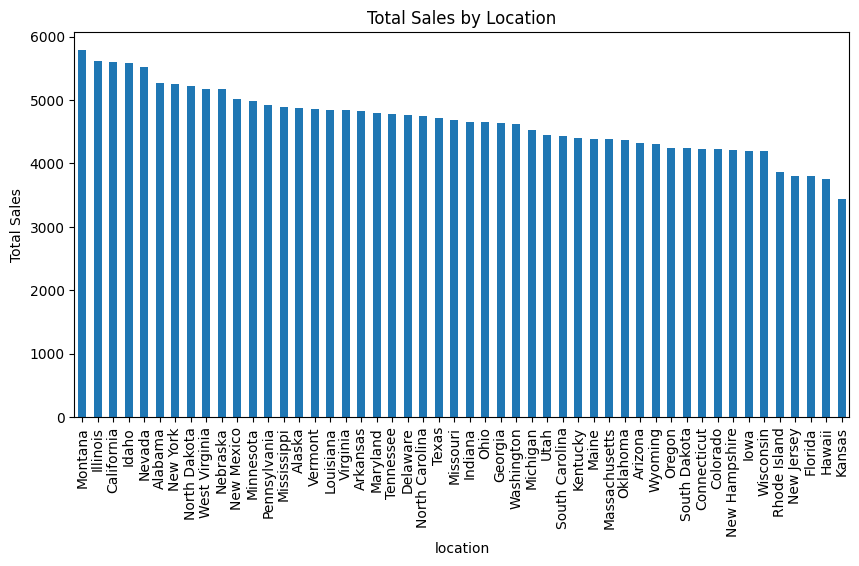

In [103]:
# Q3: Which location has highest sales?
location_sales = df.groupby('location')['purchase_amount_(usd)'].sum().sort_values(ascending=False)
print(location_sales)

location_sales.plot(kind='bar', figsize=(10,5), title="Total Sales by Location")
plt.ylabel("Total Sales")
plt.show()


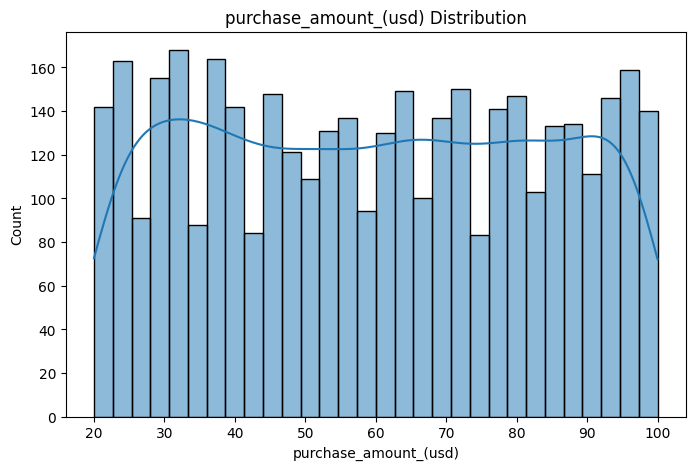

In [105]:
#Q4: What is the distribution of purchase_amount_(usd)?
plt.figure(figsize=(8,5))
sns.histplot(df['purchase_amount_(usd)'], bins=30, kde=True)
plt.title("purchase_amount_(usd) Distribution")
plt.show()

In [ ]:
# 2. Purchase behavior
# - Average purchase amount by age group
cat_revenu=df.groupby('category')['purchase_amount_(usd)'].sum()
print(cat_revenu)
# Which category has highest average spend?
cat_reve=df.groupby('category')['purchase_amount_(usd)'].mean().sort_values(ascending=False)
print("highest average spend",cat_reve)
print("Q12: Which product type sells the most?")
prd_sale_most=df.groupby("item_purchased")['purchase_amount_(usd)'].sum().sort_values(ascending=False).head(10)
print(prd_sale_most)



category
Accessories     74200
Clothing       104264
Footwear        36093
Outerwear       18524
Name: purchase_amount_(usd), dtype: int64
highest average spend category
Footwear       60.255426
Clothing       60.025331
Accessories    59.838710
Outerwear      57.172840
Name: purchase_amount_(usd), dtype: float64
Q12: Which product type sells the most?
item_purchased
Blouse        10410
Shirt         10332
Dress         10320
Pants         10090
Jewelry       10010
Sunglasses     9649
Belt           9635
Scarf          9561
Sweater        9462
Shorts         9433
Name: purchase_amount_(usd), dtype: int64


In [64]:
print("\n Most frequently purchased product types \n ")    

prd_fre= df.groupby(['item_purchased'])['purchase_amount_(usd)'].count().sort_values(ascending=False).head(10)
print(prd_fre)


      



 Most frequently purchased product types 
 
item_purchased
Jewelry       171
Blouse        171
Pants         171
Shirt         169
Dress         166
Sweater       164
Jacket        163
Coat          161
Sunglasses    161
Belt          161
Name: purchase_amount_(usd), dtype: int64


In [ ]:
print("\nrleg Category vs Product Type (Revenue Contribution)  \n ")

import pandas as pd 
pivt_table=pd.pivot_table(
    data=df,
    values='purchase_amount_(usd)',
    index='category',
    columns='item_purchased',
    aggfunc='count',
    fill_value=0

    )
print(pivt_table.head(5))


 Q14: Category vs Product Type (Revenue Contribution)  
 
item_purchased  Backpack  Belt  Blouse  Boots  Coat  Dress  Gloves  Handbag  \
category                                                                      
Accessories          143   161       0      0     0      0     140      153   
Clothing               0     0     171      0     0    166       0        0   
Footwear               0     0       0    144     0      0       0        0   
Outerwear              0     0       0      0   161      0       0        0   

item_purchased  Hat  Hoodie  ...  Scarf  Shirt  Shoes  Shorts  Skirt  \
category                     ...                                       
Accessories     154       0  ...    157      0      0       0      0   
Clothing          0     151  ...      0    169      0     157    158   
Footwear          0       0  ...      0      0    150       0      0   
Outerwear         0       0  ...      0      0      0       0      0   

item_purchased  Sneakers  Socks  

In [17]:
df.columns

Index(['customer_id', 'age', 'gender', 'item_purchased', 'category',
       'purchase_amount_(usd)', 'location', 'size', 'color', 'season',
       'review_rating', 'subscription_status', 'shipping_type',
       'discount_applied', 'previous_purchases', 'payment_method',
       'frequency_of_purchases', 'age_group', 'frequency_purchase_days'],
      dtype='str')

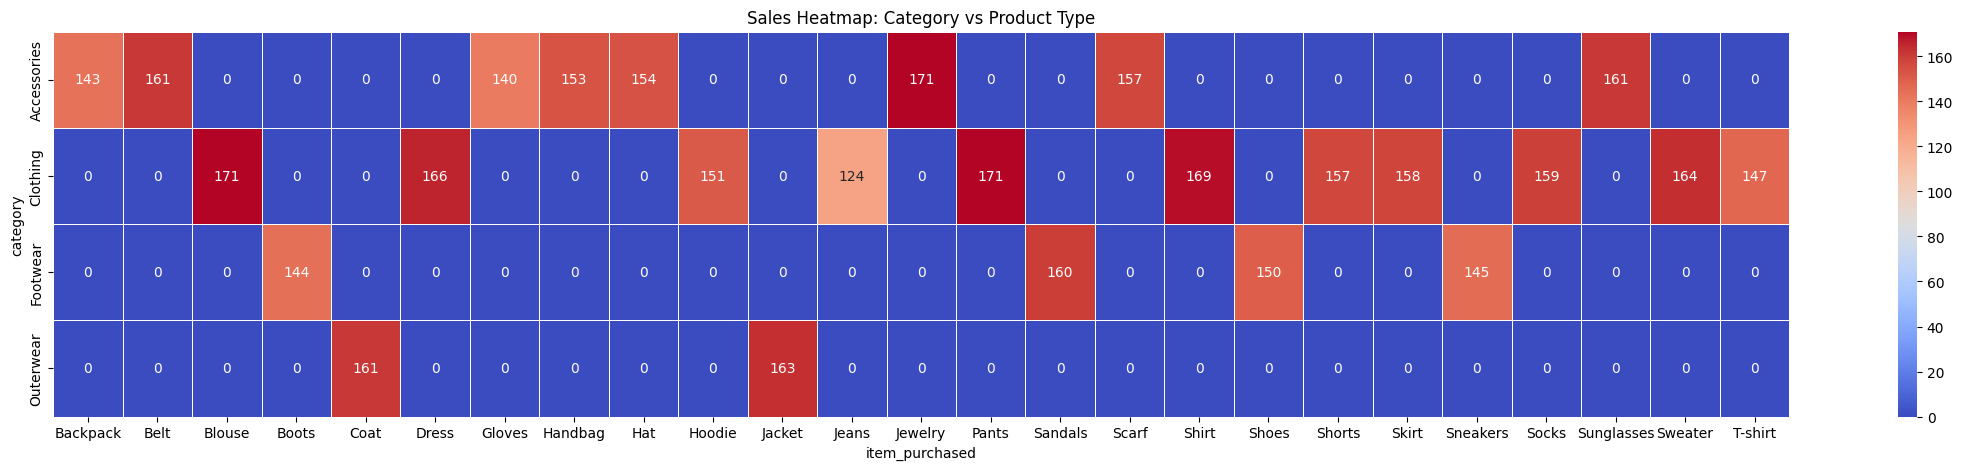

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(28,5))

# 1. annot=True shows the numbers
# 2. fmt=".0f" removes decimals (makes it cleaner)
# 3. annot_kws={"size": 10} adjusts the text size if it's too cramped
sns.heatmap(pivt_table, annot=True, fmt=".0f", cmap="coolwarm", linewidths=0.5)

plt.title("Sales Heatmap: Category vs Product Type")
plt.show()


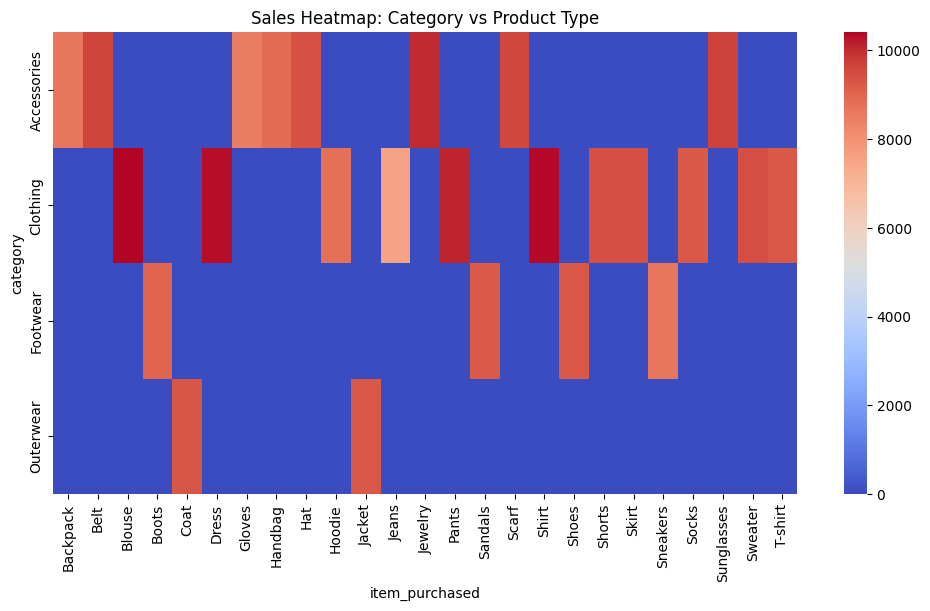

In [ ]:

# Sales Heatmap: Category vs Product Type
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(12,6))
sns.heatmap(pivt_table, cmap="coolwarm")
plt.title("Sales Heatmap: Category vs Product Type")
plt.show()

/var/folders/42/xcfzwkmn4psf2whkh2lwnmfc0000gn/T/ipykernel_57712/4225534862.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=age_revenue, x='age_group', y='purchase_amount_(usd)', palette='viridis')


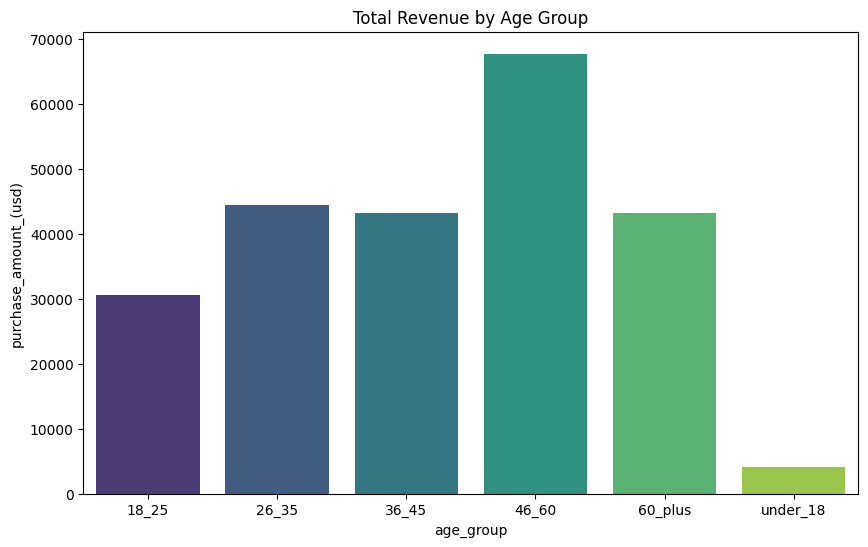

In [62]:
# Total Revenue by Age Group
import seaborn as sns
age_revenue = df.groupby('age_group')['purchase_amount_(usd)'].sum().reset_index()
plt.figure(figsize=(10, 6))
sns.barplot(data=age_revenue, x='age_group', y='purchase_amount_(usd)', palette='viridis')
plt.title('Total Revenue by Age Group')
plt.show()

# Insights from demographics: Customers aged 40-60 are the most valuable, contributing the highest revenue. This suggests that marketing efforts should focus on this age group to maximize sales.

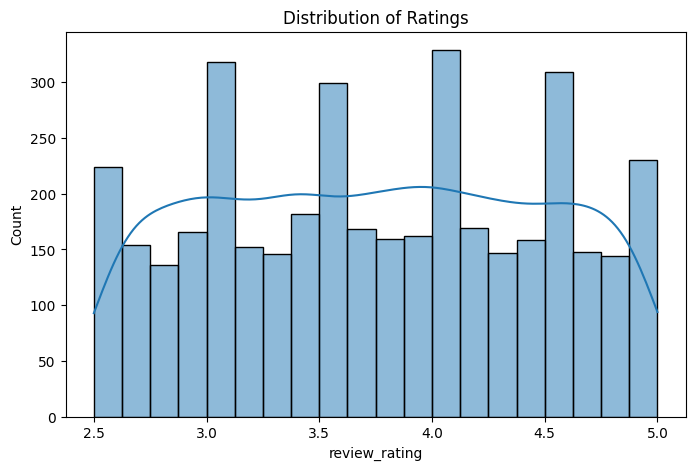

In [ ]:
#Q:-Distribution of Ratings
plt.figure(figsize=(8,5))
sns.histplot(df['review_rating'], bins=20, kde=True)
plt.title("Distribution of Ratings")
plt.show()



review_rating
2.5    62.287879
2.6    59.765823
2.7    59.363636
2.8    57.066176
2.9    56.198795
3.0    60.728395
3.1    58.782051
3.2    61.315789
3.3    59.794521
3.4    59.005495
3.5    58.072368
3.6    57.081633
3.7    60.244048
3.8    61.132075
3.9    58.913580
4.0    59.237569
4.1    61.959459
4.2    60.757396
4.3    59.673469
4.4    60.525316
4.5    59.489209
4.6    57.311765
4.7    59.283784
4.8    61.881944
4.9    63.746914
5.0    64.352941
Name: purchase_amount_(usd), dtype: float64


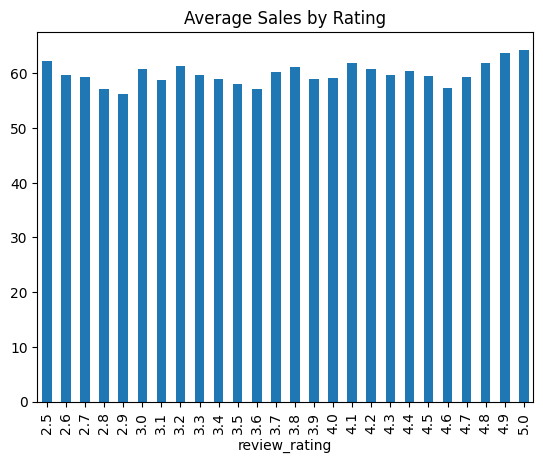

In [ ]:
# Q:- Do higher ratings lead to higher sales?
#higer_rating=df.groupby('review_rating')['customer_id'].count().sort_values(ascending=False) 
rating_sales = df.groupby('review_rating')['purchase_amount_(usd)'].mean().head(5)
rating_sales

print(rating_sales)

rating_sales.plot(kind='bar', title="Average Sales by Rating")
plt.show()


In [39]:
# 1. Filter for only 5-star ratings
five_star_customers = df[df['review_rating'] == 5.0]

# 2. Calculate the average spending for this group
avg_spend_5star = five_star_customers['purchase_amount_(usd)'].mean()

print(f"When a person gives a 5-star rating, they usually spend: ${avg_spend_5star:.2f}")


When a person gives a 5-star rating, they usually spend: $64.35


In [42]:
df[['review_rating','purchase_amount_(usd)']].corr()

,review_rating,purchase_amount_(usd)
review_rating,1.000000,0.029659
purchase_amount_(usd),0.029659,1.000000


season
Fall      60018
Spring    58679
Winter    58607
Summer    55777
Name: purchase_amount_(usd), dtype: int64


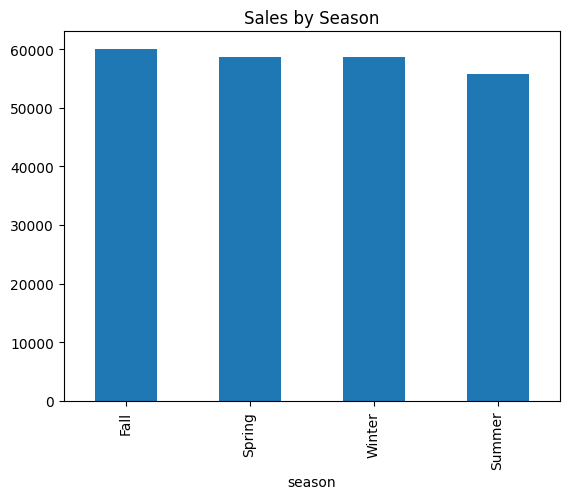

In [ ]:
#Sales by Season
sale_seas=df.groupby('season')['purchase_amount_(usd)'].sum().sort_values(ascending=False)
print(sale_seas)

sale_seas.plot(kind='bar', title="" \
"")
plt.show()

In [ ]:
# Q: Most used payment method
payment_method_counts = df['payment_method'].value_counts()
print(payment_method_counts)
# Q: Revenue by payment method
payment_method_counts = df.groupby('payment_method')['purchase_amount_(usd)'].sum().sort_values(ascending=False)
print(payment_method_counts)
#Q: Average spend by payment type
payment_method_avg = df.groupby('payment_method')['purchase_amount_(usd)'].mean().sort_values(ascending=False)
print(payment_method_avg)


payment_method
PayPal           677
Credit Card      671
Cash             670
Debit Card       636
Venmo            634
Bank Transfer    612
Name: count, dtype: int64
payment_method
Credit Card      40310
PayPal           40109
Cash             40002
Debit Card       38742
Venmo            37374
Bank Transfer    36544
Name: purchase_amount_(usd), dtype: int64
payment_method
Debit Card       60.915094
Credit Card      60.074516
Bank Transfer    59.712418
Cash             59.704478
PayPal           59.245199
Venmo            58.949527
Name: purchase_amount_(usd), dtype: float64


In [43]:
df.columns

Index(['customer_id', 'age', 'gender', 'item_purchased', 'category',
       'purchase_amount_(usd)', 'location', 'size', 'color', 'season',
       'review_rating', 'subscription_status', 'shipping_type',
       'discount_applied', 'previous_purchases', 'payment_method',
       'frequency_of_purchases', 'age_group', 'frequency_purchase_days'],
      dtype='str')

In [60]:
freq_sum=df.groupby('frequency_of_purchases')['purchase_amount_(usd)'].sum().sort_values(ascending=False)
print(freq_sum)


freq_sum=df.groupby(['frequency_of_purchases','gender'])['customer_id'].count().sort_values(ascending=False)
print(freq_sum)


frequency_of_purchases
Every 3 Months    35088
Annually          34419
Quarterly         33771
Bi-Weekly         33200
Monthly           32810
Fortnightly       32007
Weekly            31786
Name: purchase_amount_(usd), dtype: int64
frequency_of_purchases  gender
Every 3 Months          Male      398
Quarterly               Male      394
Annually                Male      387
Fortnightly             Male      379
Monthly                 Male      368
Weekly                  Male      367
Bi-Weekly               Male      359
                        Female    188
Every 3 Months          Female    186
Annually                Female    185
Monthly                 Female    185
Weekly                  Female    172
Quarterly               Female    169
Fortnightly             Female    163
Name: customer_id, dtype: int64


In [55]:
#2. Who are high-frequency purchasers?
# Count rows where previous_purchases is greater than 0
repeat_buyers = df[df['previous_purchases'] > 0]
print(f"Number of repeat buyers: {len(repeat_buyers)}")


# Filter for the most active shopping frequencies
high_freq_purchasers = df[df['frequency_of_purchases'].isin(['Weekly', 'Bi-Weekly'])]
print(high_freq_purchasers[['customer_id', 'age', 'category']])


Number of repeat buyers: 3900
      customer_id  age     category
2               3   50     Clothing
3               4   21     Footwear
5               6   46     Footwear
7               8   27     Clothing
10             11   53     Footwear
...           ...  ...          ...
3888         3889   45     Footwear
3893         3894   21  Accessories
3895         3896   40     Clothing
3896         3897   52  Accessories
3898         3899   44     Footwear

[1086 rows x 3 columns]


In [56]:
high_freq_purchasers

,customer_id,age,gender,item_purchased,category,purchase_amount_(usd),location,size,color,season,review_rating,subscription_status,shipping_type,discount_applied,previous_purchases,payment_method,frequency_of_purchases,age_group,frequency_purchase_days
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,23,Credit Card,Weekly,46_60,7
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,49,PayPal,Weekly,18_25,7
5,6,46,Male,Sneakers,Footwear,20,Wyoming,M,White,Summer,2.9,Yes,Standard,Yes,14,Venmo,Weekly,46_60,7
7,8,27,Male,Shorts,Clothing,34,Louisiana,L,Charcoal,Winter,3.2,Yes,Free Shipping,Yes,19,Credit Card,Weekly,26_35,7
10,11,53,Male,Shoes,Footwear,34,Arkansas,L,Purple,Fall,4.1,Yes,Store Pickup,Yes,26,Bank Transfer,Bi-Weekly,46_60,14
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3888,3889,45,Female,Sneakers,Footwear,69,Virginia,M,Violet,Spring,3.4,No,Standard,No,14,Venmo,Bi-Weekly,36_45,14
3893,3894,21,Female,Hat,Accessories,64,Massachusetts,L,White,Fall,3.3,No,Store Pickup,No,29,Bank Transfer,Bi-Weekly,18_25,14
3895,3896,40,Female,Hoodie,Clothing,28,Virginia,L,Turquoise,Summer,4.2,No,2-Day Shipping,No,32,Venmo,Weekly,36_45,7
3896,3897,52,Female,Backpack,Accessories,49,Iowa,L,White,Spring,4.5,No,Store Pickup,No,41,Bank Transfer,Bi-Weekly,46_60,14


In [65]:
df.columns

Index(['customer_id', 'age', 'gender', 'item_purchased', 'category',
       'purchase_amount_(usd)', 'location', 'size', 'color', 'season',
       'review_rating', 'subscription_status', 'shipping_type',
       'discount_applied', 'previous_purchases', 'payment_method',
       'frequency_of_purchases', 'age_group', 'frequency_purchase_days'],
      dtype='str')

In [69]:
# Q:- Comapre the average purchase amount between Standard and Express Shipping

data_shi=df[df['shipping_type'].isin(['Standard', 'Express'])]
shipping_avg=data_shi.groupby('shipping_type')['purchase_amount_(usd)'].mean().sort_values(ascending=False)
print(shipping_avg)


shipping_type
Express     60.475232
Standard    58.460245
Name: purchase_amount_(usd), dtype: float64


In [ ]:
#Q:-Do you Subscribed customer spend more than non subscribed customers? Compare the average purchase amount between subscribed and non-subscribed customers.
subscribed = df.groupby('subscription_status').agg(
    total_customer=('customer_id', 'count'),
    avg_spend=('purchase_amount_(usd)', 'mean'),
    total_revenue=('purchase_amount_(usd)', 'sum')
).round({'avg_spend': 2}).sort_values(by='avg_spend')

print(subscribed)


                     total_customer  avg_spend  total_revenue
subscription_status                                          
Yes                            1053      59.49          62645
No                             2847      59.87         170436


In [90]:
subscribed     = df['subscription_status'][df['subscription_status'] == 'Yes']
type(subscribed)

pandas.Series

In [106]:
subscribed = df.groupby('subscription_status')['customer_id'].count().sort_values(ascending=True)
avg_spend = df.groupby('subscription_status')['purchase_amount_(usd)'].mean().sort_values(ascending=True)
total_spend = df.groupby('subscription_status')['purchase_amount_(usd)'].sum().sort_values(ascending=True)

print(subscribed)
print(avg_spend)
print(total_spend)


subscription_status
Yes    1053
No     2847
Name: customer_id, dtype: int64
subscription_status
Yes    59.491928
No     59.865121
Name: purchase_amount_(usd), dtype: float64
subscription_status
Yes     62645
No     170436
Name: purchase_amount_(usd), dtype: int64


In [ ]:
subscribed = df.groupby('subscription_status').agg(
    total_customer=('customer_id', 'count'),
    avg_spend=('purchase_amount_(usd)', 'mean'),
    total_revenue=('purchase_amount_(usd)', 'sum')
).round({'avg_spend': 2}).sort_values(by='avg_spend')

print(subscribed)



                     total_customer  avg_spend  total_revenue
subscription_status                                          
Yes                            1053      59.49          62645
No                             2847      59.87         170436


In [ ]:
#Q:- How can customers be segmented into new, returning, and loyal categories based on their purchase frequency, and what is the count of customers across each segments?
# bins: fence posts on the number line
bins   = [0, 1, 8, float('inf')]

# labels: name for each bucket
labels = ['New', 'Returning', 'Loyal']

# cut and create new column
df['customer_segment'] = pd.cut(
    df['previous_purchases'],
    bins=bins,
    labels=labels
)
#count each segment
segment_counts = df['customer_segment'].value_counts().reset_index()
print(segment_counts)




  customer_segment  count
0            Loyal   3257
1        Returning    560
2              New     83


In [129]:
df.head()

,customer_id,age,gender,item_purchased,category,purchase_amount_(usd),location,size,color,season,review_rating,subscription_status,shipping_type,discount_applied,previous_purchases,payment_method,frequency_of_purchases,age_group,frequency_purchase_days
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,14,Venmo,Fortnightly,46_60,14
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,2,Cash,Fortnightly,18_25,14
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,23,Credit Card,Weekly,46_60,7
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,49,PayPal,Weekly,18_25,7
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,31,PayPal,Annually,36_45,365


In [136]:
mm=df['previous_purchases']>5
print(mm)

df['mm']=df['previous_purchases']>5
print(mm)

mm=df[df['previous_purchases']>5]
print(mm)

0        True
1       False
2        True
3        True
4        True
        ...  
3895     True
3896     True
3897     True
3898     True
3899     True
Name: previous_purchases, Length: 3900, dtype: bool
0        True
1       False
2        True
3        True
4        True
        ...  
3895     True
3896     True
3897     True
3898     True
3899     True
Name: previous_purchases, Length: 3900, dtype: bool
      customer_id  age  gender item_purchased     category  \
0               1   55    Male         Blouse     Clothing   
2               3   50    Male          Jeans     Clothing   
3               4   21    Male        Sandals     Footwear   
4               5   45    Male         Blouse     Clothing   
5               6   46    Male       Sneakers     Footwear   
...           ...  ...     ...            ...          ...   
3895         3896   40  Female         Hoodie     Clothing   
3896         3897   52  Female       Backpack  Accessories   
3897         3898   46  Female

In [ ]:
#Are customers who are reapeta buyers (more than 5 preivios puschase ) are likely to subscribe and what percentage?

'''cust_subc=df[df['previous_purchases']>5]['subscription_status'].value_counts()
print(cust_subc)'''



repeat_buyers = df[df['previous_purchases']>5]
print(repeat_buyers[['customer_id', 'previous_purchases', 'subscription_status']])      


      customer_id  previous_purchases subscription_status
0               1                  14                 Yes
2               3                  23                 Yes
3               4                  49                 Yes
4               5                  31                 Yes
5               6                  14                 Yes
...           ...                 ...                 ...
3895         3896                  32                  No
3896         3897                  41                  No
3897         3898                  24                  No
3898         3899                  24                  No
3899         3900                  33                  No

[3476 rows x 3 columns]


In [137]:
df

,customer_id,age,gender,item_purchased,category,purchase_amount_(usd),location,size,color,season,review_rating,subscription_status,shipping_type,discount_applied,previous_purchases,payment_method,frequency_of_purchases,age_group,frequency_purchase_days,mm
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,14,Venmo,Fortnightly,46_60,14,True
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,2,Cash,Fortnightly,18_25,14,False
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,23,Credit Card,Weekly,46_60,7,True
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,49,PayPal,Weekly,18_25,7,True
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,31,PayPal,Annually,36_45,365,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3895,3896,40,Female,Hoodie,Clothing,28,Virginia,L,Turquoise,Summer,4.2,No,2-Day Shipping,No,32,Venmo,Weekly,36_45,7,True
3896,3897,52,Female,Backpack,Accessories,49,Iowa,L,White,Spring,4.5,No,Store Pickup,No,41,Bank Transfer,Bi-Weekly,46_60,14,True
3897,3898,46,Female,Belt,Accessories,33,New Jersey,L,Green,Spring,2.9,No,Standard,No,24,Venmo,Quarterly,46_60,90,True
3898,3899,44,Female,Shoes,Footwear,77,Minnesota,S,Brown,Summer,3.8,No,Express,No,24,Venmo,Weekly,36_45,7,True


In [125]:
segment_counts

,customer_segment,count
0,Loyal,3257
1,Returning,560
2,New,83
